Universidad Torcuato Di Tella

Licenciatura en Tecnología Digital

**TD VI: Inteligencia Artificial**

# **Trabajo Práctico N°2**

El objetivo de este Trabajo Práctico es que experimenten el ciclo de vida completo de un
proyecto de Machine Learning en un entorno competitivo real. Deberán resolver un problema de
clasificación multiclase utilizando datos de la industria musical, participando en una competencia
interna en Kaggle, y luego contrastando las métricas de laboratorio con el verdadero impacto
en el negocio.

Trabajarán con un dataset basado en métricas acústicas de Spotify. El objetivo es predecir a
qué género musical pertenece una canción basándose en otras características (como *danceability*,
*energy*, *tempo*, etc.).

### **Preparación del entorno de trabajo**

A continuación, se instalan todos los paquetes a utilizar durante la realización del presente trabajo. `requirements.txt` es la lista de todos los paquetes necesarios. La siguiente celda ahorra el trabajo de instalar manualmente (descomentar para usar).

In [1]:
# !pip install -r requirements.txt

Luego se importan los módulos de interés. Los más importantes son:
- `scikit learn` : para implementar modelos de ML y computar métricas relevantes. Esta librería y sus métodos serán incorporados más adelante de acuerdo a la necesidad.
- `pandas` y `numpy` : para visualizar y manipular datos y datasets.
- `matplotlib` y `seaborn` : para confeccionar visualizaciones de los datos obtenidos.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Con todo esto, ya se puede comenzar a analizar y visualizar el dataset.

### **Análisis Exploratorio de Datos (EDA)**

Primero, se debe importar el dataset de entrenamiento con `pandas`.

In [3]:
# El método `read_csv` nos permite leer un archivo .csv y parsearlo a un dataframe de pandas
dataset:pd.DataFrame = pd.read_csv("dataset/train.csv")

# Imprimimos las primeras diez muestras del dataset usando el método `.head(10)`
dataset.head(10)

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,Expected,Id
0,0,143733,False,0.439,0.196,0,-16.093,1,0.0601,0.88000,0.000000,0.0513,0.5250,129.581,4,jazz,4271
1,0,261562,False,0.627,0.876,11,-4.391,0,0.0324,0.01590,0.000000,0.0665,0.4180,111.950,4,electronic,2078
2,63,190131,False,0.767,0.869,2,-3.381,0,0.0908,0.14000,0.000000,0.2210,0.7510,98.208,4,hip-hop,4921
3,48,201440,False,0.374,0.183,9,-13.225,1,0.0281,0.89700,0.038700,0.1090,0.1340,82.042,4,acoustic,4206
4,0,168552,True,0.423,0.721,0,-8.070,1,0.1650,0.00792,0.000000,0.3800,0.3820,161.926,4,rock,2423
5,0,251506,False,0.664,0.744,0,-8.318,1,0.0543,0.28400,0.858000,0.9370,0.4630,95.138,4,jazz,4635
6,0,167450,False,0.449,0.836,2,-2.910,0,0.0370,0.00074,0.000000,0.3130,0.6940,141.900,4,electronic,3203
7,37,218453,True,0.599,0.640,4,-5.186,1,0.0313,0.06430,0.000945,0.0783,0.3950,125.949,4,electronic,1960
8,0,141540,False,0.456,0.314,7,-9.309,0,0.0347,0.24900,0.000000,0.0819,0.4370,131.821,4,rock,2308
9,71,213733,False,0.818,0.799,1,-4.100,0,0.1560,0.00107,0.128000,0.0570,0.0815,100.014,4,electronic,3298


Se observa la cantidad de datos que se dispone en el dataset.

In [4]:
# El atributo `.shape` nos devuelve las dimensiones del dataframe (en este caso el dataset)
print(f'Se disponen de {dataset.shape[0]} muestras distribuidas a lo largo de {dataset.shape[1]} features.')

Se disponen de 4200 muestras distribuidas a lo largo de 17 features.


Se averigua el tipo de dato correspondiente a cada feature.

In [5]:
# Las columnas y su tipo de dato correspondiente
dataset.dtypes

popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
Expected             object
Id                    int64
dtype: object

Se tiene, entonces, que el dataset cuenta con **15 columnas de tipo numérico (`int64` y `float64`)**, 1 columna de tipo booleano (`explicit`) y 1 columna categórica correspondiente a la variable dependiente `Expected` (el género musical). La feature `Id` no es tenida en cuenta para este análisis.

Se aborda la cuestión respecto a posibles muestras duplicadas.

In [14]:
# Duplicados considerando todas las columnas excepto Id, que es único por cada muestra
print("Filas duplicadas (todas las columnas):", dataset.drop(columns=["Id"]).duplicated().sum())

# Duplicados considerando solo las features de audio, ignorando el género
cols_audio = dataset.columns.drop(["Id", "Expected"])
dup_mask = dataset.duplicated(subset=cols_audio, keep=False)
print("Filas con features de audio repetidas:", dup_mask.sum())

# De esos grupos duplicados contamos las muestras que poseen distinto género a pesar de tener
# los mismos valores para las features de audio
grupos_ambiguos = dataset[dup_mask].groupby(list(cols_audio))["Expected"].nunique()
print("Grupos con más de un género para el mismo perfil de audio:", (grupos_ambiguos > 1).sum())

Filas duplicadas (todas las columnas): 663
Filas con features de audio repetidas: 938
Grupos con más de un género para el mismo perfil de audio: 17


Se desea observar si existe correlación entre algunas de las variables del dataset, así como también la distribución de cada variable para cada género. Para ello, se genera una serie de *scatter plots*. La primera selección de variables incluye `danceability`, `energy`, `instrumentalness`, `loudness`, `speechiness`, `acousticness` y `tempo`. A partir de los gráficos resultantes, vamos a sacar conclusiones respecto de los datos.

/media/arotu/HDD/facultad/UTDT/S2_2026/TD VI/TP-VI-TP2/.venv/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/media/arotu/HDD/facultad/UTDT/S2_2026/TD VI/TP-VI-TP2/.venv/lib/python3.12/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/media/arotu/HDD/facultad/UTDT/S2_2026/TD VI/TP-VI-TP2/.venv/lib/python3.12/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset 

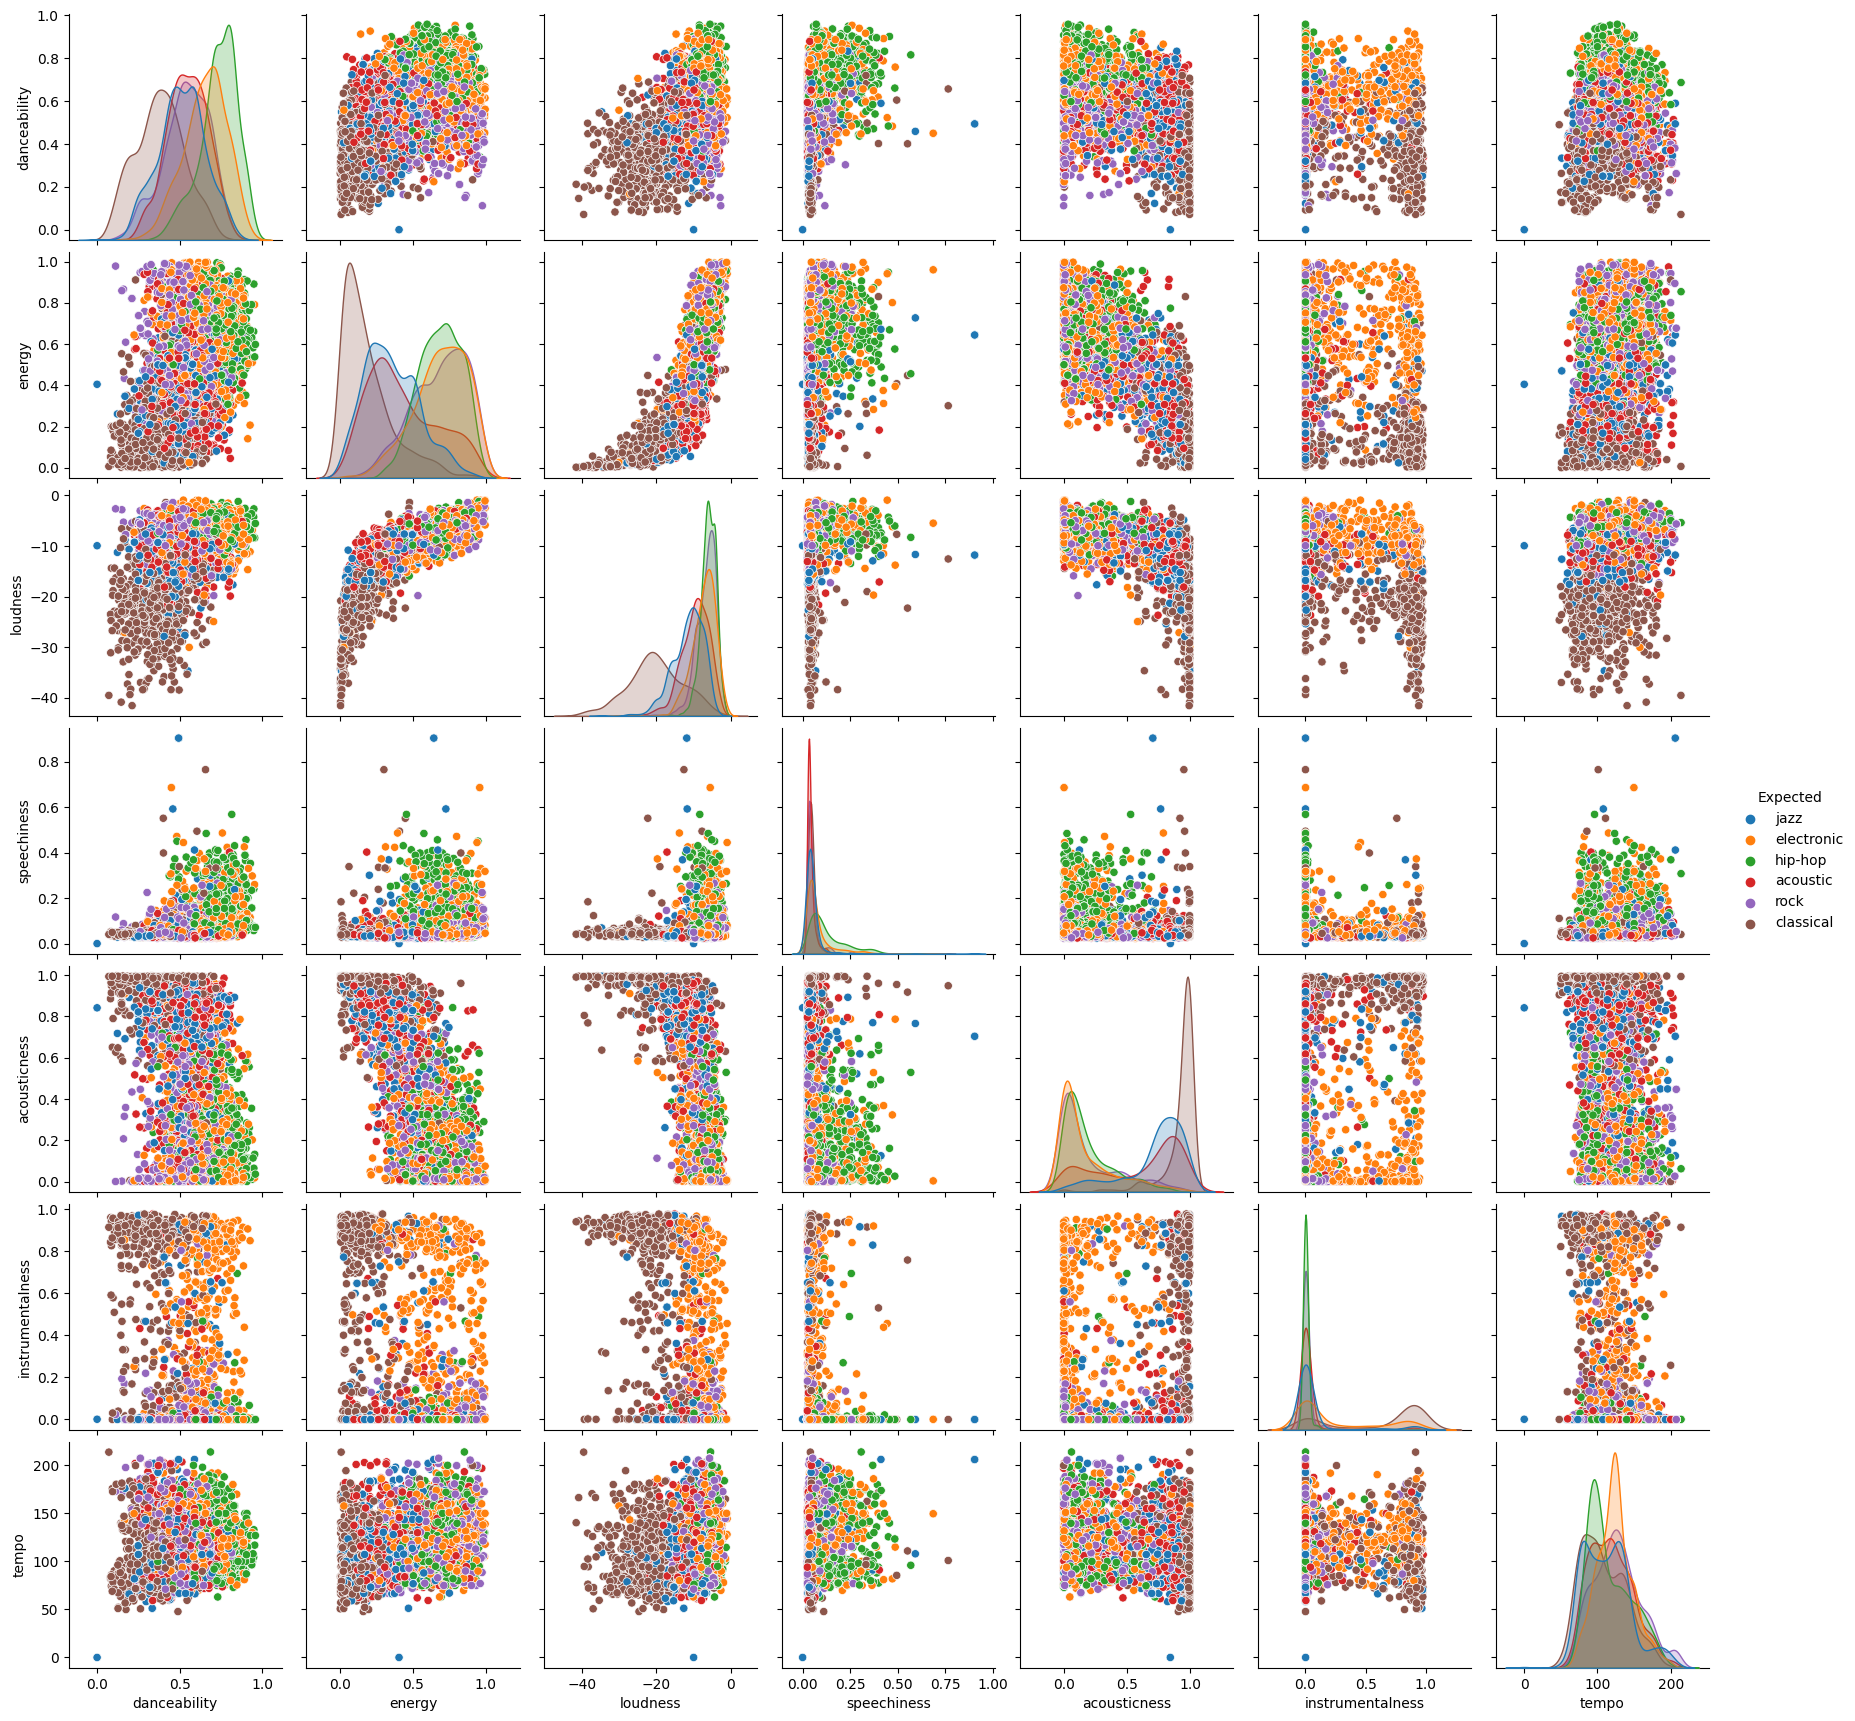

In [7]:
# Generamos el pairplot para explorar visualmente la correlacion entre variables y la distribucion de cada una por genero musical
sns.pairplot(data=dataset, hue="Expected", vars=["danceability", "energy", "loudness", "speechiness",	"acousticness", "instrumentalness", "tempo"])

Hay pares de variables que parecieran mostrar algún tipo de correlación entre sí:

- `danceability` y `energy` parecieran exhibir una correlación positiva, aunque en apariencia débil.
- `danceability` y `acousticness` también exhiben una correlación débil, aunque negativa.
- `energy` y `loudness` tienen una correlación positiva bien marcada que se asimila a una función cuadrática lo cual parece razonable.
- `energy` y `acousticness` exhiben una correlación negativa débil.


Luego, se pueden observar algunas diferencias bien específicas entre cada género de música:
- A simple vista, se puede inferir que la música clásica va a ser la más fácil de predecir. Para casi todos los features, tiene una media y distribución bien diferenciada del resto de los géneros. Algunas de las variables donde más se nota este fenómeno son `loudness`, `energy`, `acousticness` e `instrumentalness`. Esto tiene sentido, puesto que la música clásica tiende a incorporar una cantidad mucho mayor de instrumentos tradicionales y es "más tranquila" en comparación a otros géneros.

Pasamos a comparar las características numéricas por género. 

Esto nos va a ayudar a ver si cada género tiene valores mas altos en ciertos features comparados con otros, y asi ver si tienen perfiles sonoros diferentes.

In [8]:
# No usamos la columna "Id" para el análisis, ya que a pesar de ser una variable númerica,no es una característica relevante para el género musical
# Incluímos explícitamente `explicit`
cols_numericas = dataset.select_dtypes(include=['bool', 'number']).columns.drop("Id")

medias_por_genero = dataset.groupby("Expected")[cols_numericas].mean()

# Normalizamos cada característica para poder compararlas
# Es necesario normalizar los valores, ya que `duration_ms` siempre tiene valores altos, dificultando la comparación con los otros features
medias_por_genero_norm = (medias_por_genero - medias_por_genero.min()) / (medias_por_genero.max() - medias_por_genero.min())
medias_por_genero_norm

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
Expected,,,,,,,,,,,,,,,
acoustic,0.969531,0.544144,0.176471,0.467456,0.481394,0.588339,0.746012,1.000,0.000000,0.540221,0.044237,0.000000,0.241449,0.546500,0.685
classical,0.000000,0.977182,0.000000,0.000000,0.000000,0.079505,0.000000,0.792,0.087481,1.000000,1.000000,0.345471,0.000000,0.000000,0.000
electronic,1.000000,1.000000,0.416290,0.770075,1.000000,0.895760,0.907037,0.120,0.437697,0.000000,0.421838,1.000000,0.105140,0.822601,0.980
hip-hop,0.801608,0.357125,1.000000,1.000000,0.995101,1.000000,1.000000,0.000,1.000000,0.025081,0.000000,0.969028,1.000000,0.444872,1.000
jazz,0.011146,0.000000,0.009050,0.371642,0.332970,0.000000,0.609523,0.796,0.125417,0.728671,0.114749,0.453686,0.681878,0.243428,0.480
rock,0.200493,0.671871,0.158371,0.446292,0.987667,0.791519,0.954017,0.652,0.081611,0.032498,0.018676,0.424294,0.908815,1.000000,0.815


Para poder observar los cambios de manera mas clara, se renderiza el siguiente heatmap.

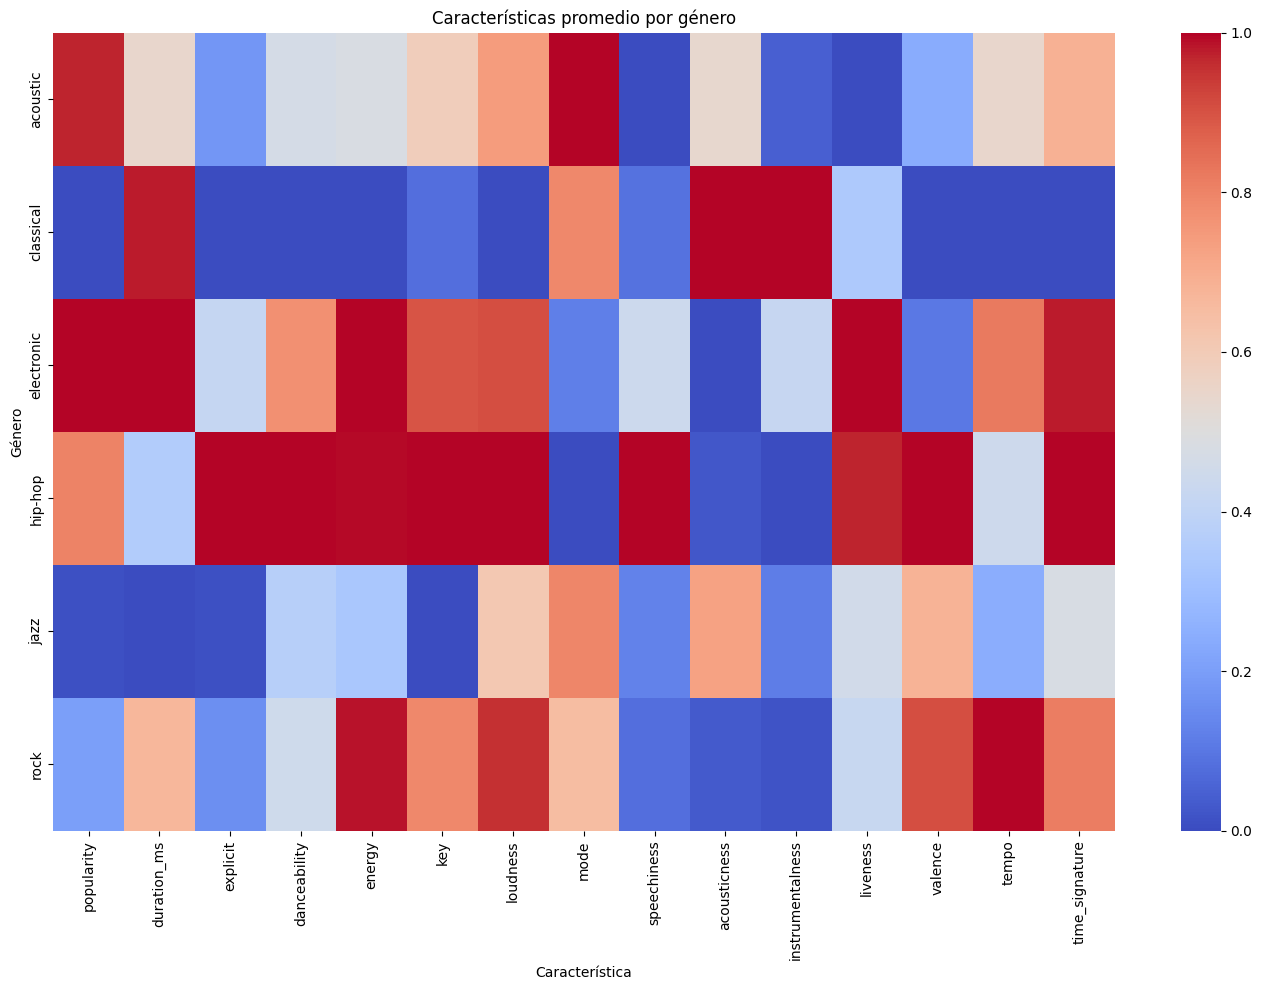

In [9]:
# Delimitamos las dimensiones de la figura
plt.figure(figsize=(14, 10))

# Hacemos un heatmap para evaluar cuán grandes son los valores
# de cada variable dependiente (media normalizada) según el
# valor que toma la variable independiente
sns.heatmap(
    medias_por_genero_norm,
    cmap="coolwarm",
)

plt.title("Características promedio por género")
plt.xlabel("Característica")
plt.ylabel("Género")

plt.tight_layout()
plt.show()

Podemos notar un par de cosas:
- Como habíamos intuido antes, la música clásica parece estar vinculada a valores altos de ```acousticness``` e ```instrumentalness```.
- Los géneros con mayor popularidad son la electrónica, la música acústica y el hip-hop.
- La música clásica, y la electrónica aparentan tener canciones mas largas que el resto.
- El género que presenta un mayor valor de ```speechiness``` es el hip-hop, lo cual es esperable, siendo este un género cuyo foco esta principalmente puesto en las letras de las canciones.
- La música clásica se diferencia casi totalmente del hip-hop en la mayoría de características.

Luego, otra cosa que vale la pena observar, es la distribución de la variable objetivo para verificar si hay desbalance entre las clases.

Esto es particularmente relevante ya que un desbalance significativo **podría hacer que la accuracy no represente adecuadamente el desempeño del modelo sobre todas las clases**.

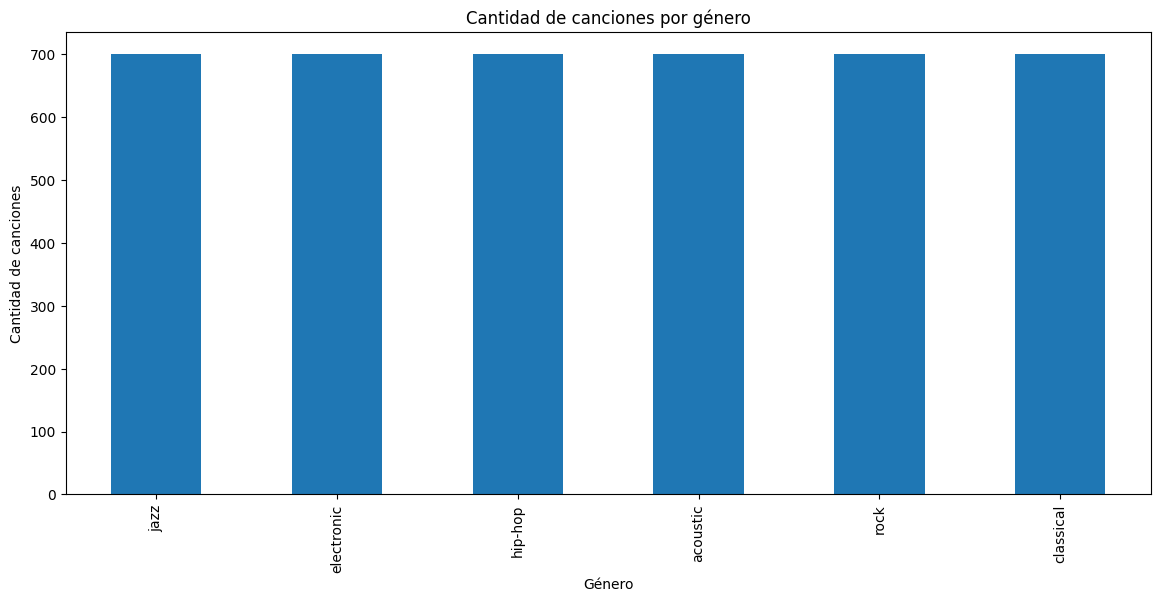

In [10]:
class_counts = dataset["Expected"].value_counts()

plt.figure(figsize=(14, 6))

class_counts.plot(kind="bar")

plt.title("Cantidad de canciones por género")
plt.xlabel("Género")
plt.ylabel("Cantidad de canciones")
plt.show()

Se observa que todos los géneros musicales cuentan con la misma cantidad de observaciones en el conjunto de entrenamiento. Por lo tanto, no existe un desbalance entre las clases y cada género tiene la misma representación en los datos. Esto permite utilizar métricas como accuracy sin que una clase mayoritaria domine el resultado.

Por último, se reduce la dimensionalidad de las features númerica a 3 componentes mediante **PCA**, para visualizar en 3D qué tan separables son los géneros musicales usando las tres features más signficativas que puedan formarse a partir las features originales (a diferencia de los scatter plots que solo comparaban pares de las variables originales).

Antes de aplicar ambas técnicas, se estandarizan las features con `StandardScaler`, ya que tanto PCA es sensible a la escala de las variables (como ya se vió con el caso de `duration_ms`).

In [11]:
from sklearn.preprocessing import StandardScaler

# Estandarizamos las features numéricas (media 0, desvío 1) para que ninguna
# domine la reducción de dimensionalidad solo por tener una escala mayor
scaler = StandardScaler()

# Ajustamos y transformamos según `scaler` a partir de las muestras que disponemos
X_scaled = scaler.fit_transform(dataset[cols_numericas])

# Separamos la variable dependiente
y_labels = dataset["Expected"]

Tras la estandarización de las variables númerica, se procede con la implementación del **PCA (de 3 componentes)**.

In [12]:
import plotly.express as px
import plotly.io as pio
from sklearn.decomposition import PCA

# Aclaramos que la renderización se dará dentro del Jupyter Notebook
pio.renderers.default = "notebook"

# Determinamos el PCA de 3 componentes
pca = PCA(n_components=3)

# Ajustamos y transformamos el conjunto de datos ya escalado con el PCA
X_pca = pca.fit_transform(X_scaled)

# Creamos nuestro nuevo "dataset" tras haber aplicado PCA
# Aquí contamos con las mismas muestras, pero explicadas a partir
# de los 3 componentes principales formados con las features
# númericas originales
pca_df = pd.DataFrame(data=X_pca, columns=["PC1", "PC2", "PC3"])

# Añadimos la variable dependiente al nuevo "dataset"
pca_df["Genero"] = y_labels

# Creamos un scatter 3D para visualizar las muestras según las tres features
# que disponemos ahora y usamos el canal del color para marcar el label
fig = px.scatter_3d(pca_df, x="PC1", y="PC2", z="PC3", color="Genero")

# Configuramos el plot
fig.update_layout(
    scene=dict(
        xaxis=dict(title="PC1"),
        yaxis=dict(title="PC2"),
        zaxis=dict(title="PC3"),
    ),
    title="PCA (3 componentes) por género musical",
)

# Renderizamos la figura
fig.show()

# Imprimimos la varianza explicada por cada componente individual y la acumulada
# entre los tres, para evaluar cuánta de la dispersión o varianza del dataset
# original logran alcanzar los 3 componentes principales
print("Varianza explicada por componente:", pca.explained_variance_ratio_)
print("Varianza explicada acumulada:", round(pca.explained_variance_ratio_.sum(), 2))

Varianza explicada por componente: [0.2582036  0.08842632 0.07943822]
Varianza explicada acumulada: 0.43


El método de PCA es determinístico, por lo que los componentes principales y su varianza explicada son reproducibles ante el mismo dataset. La varianza explicada indica qué proporción de la variabilidad total de las features originales queda representada en cada componente.

En este caso, los tres componentes principales explican en conjunto solo un $44,6\%$ de la varianza total. Por ende, más de la mitad de la varianza de las features originales escapa a lo hecho por el PCA (de 3 componentes). Además, a partir de la varianza explicada por componente se deduce que los siguientes componentes principales tampoco aportarían una varianza sustancialmente grande. Aún así, se nota que `classical` aparece claramente separado del resto (más que nada del `hip-hop`) lo cual coincide con los patrones detectados antes en el heatmap, pero los demás géneros se superponen bastante en la nube de puntos, sin fronteras claras. Esto sugiere que **la relación entre las  sda y el género musical no es puramente lineal**, o que **se necesitarían varios componentes adicionales para capturar mejor la separación entre clases**.

### **Preprocesamiento de los datos**

#### **Datos faltantes**

Se busca detectar la existencia de datos faltantes en el dataset.

In [13]:
# Calculamos la proporción de datos faltantes tipo NaN para cada feature
dataset.isna().sum() / len(dataset)

popularity          0.0
duration_ms         0.0
explicit            0.0
danceability        0.0
energy              0.0
key                 0.0
loudness            0.0
mode                0.0
speechiness         0.0
acousticness        0.0
instrumentalness    0.0
liveness            0.0
valence             0.0
tempo               0.0
time_signature      0.0
Expected            0.0
Id                  0.0
dtype: float64

Aparentemente, de los datos que se dispone, no hay datos faltantes. Por ende, no hay necesidad de tener que elegir alguna estrategia de imputación de datos.

### **Implementación de los modelos**

Descripción

### **Búsqueda de hiperparámetros**

Descripción

### **Model Selection**

Descripción

### **Métricas de laboratorio y métricas de impacto en el negocio**

Descripción

#### **Implementación de la métrica $\text{MAP@3}$**

Descripción

#### **Comparación del rendimientos de los modelos**

Descripción

#### **Optimización de la métrica $\text{MAP@3}$**

Descripción

#### **Sobre el uso de métricas**

Descripción